In [1]:
import pennylane as qml
from scipy.linalg import expm 
from pennylane import numpy as np
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt

2025-12-05 14:45:26.259404: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-05 14:45:26.314328: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-05 14:45:26.358017: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764942326.398698   92658 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764942326.410601   92658 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764942326.500192   92658 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

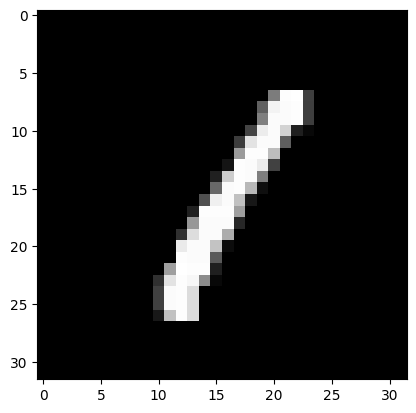

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_n1 = x_train[y_train == 1]
x_train_n1_32 = np.pad(x_train_n1, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
Image1 = x_train_n1_32[0]

plt.imshow(Image1, cmap='gray')
plt.show()

/tmp/ipykernel_92658/863995520.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


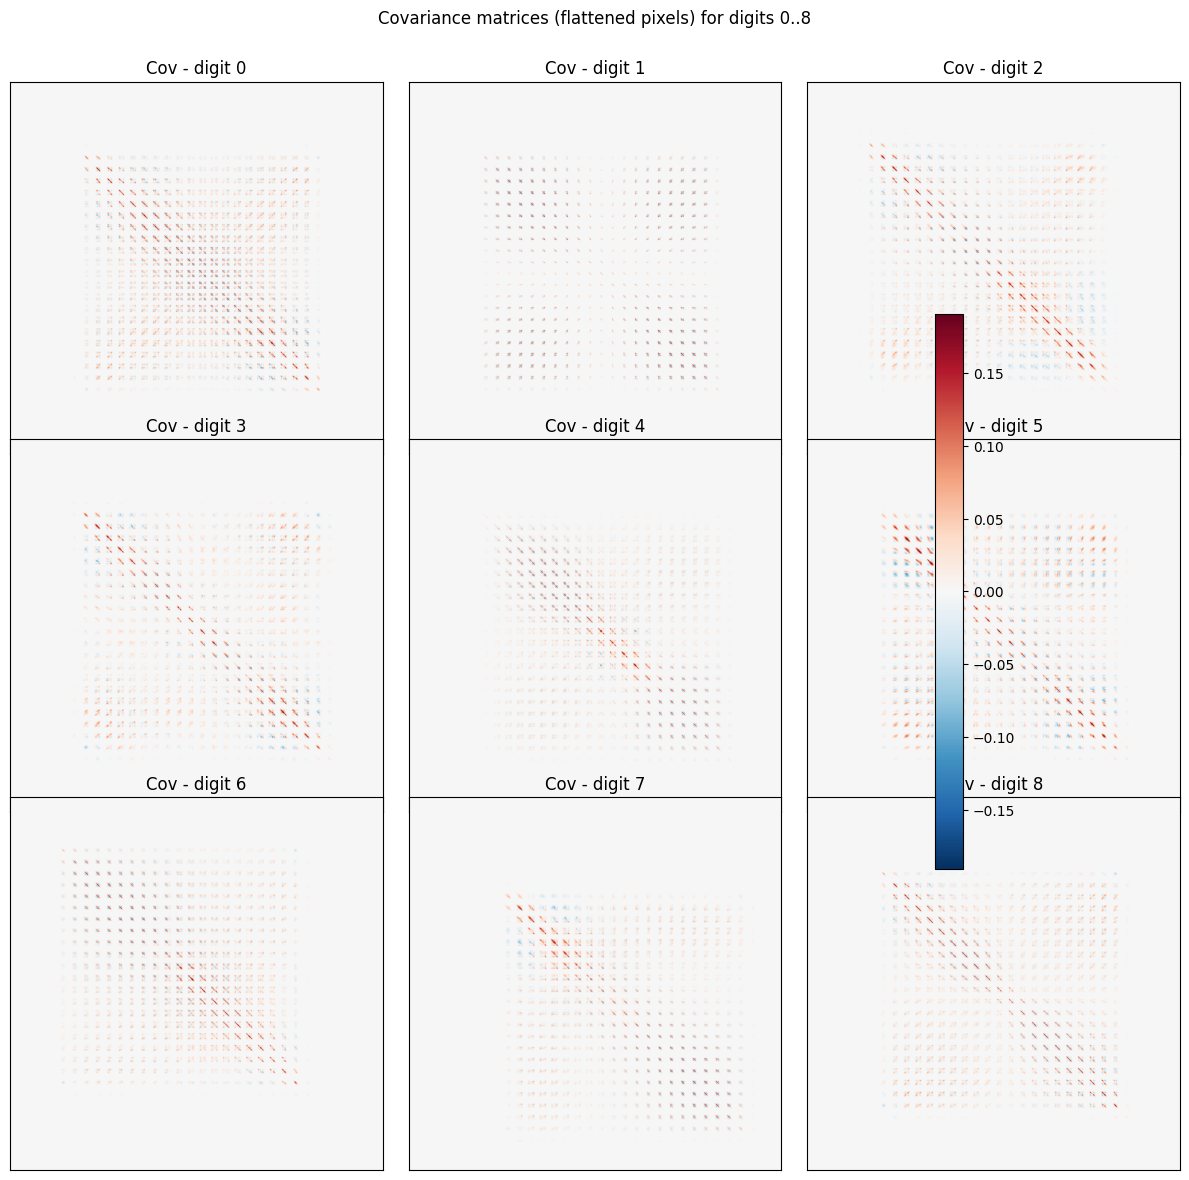

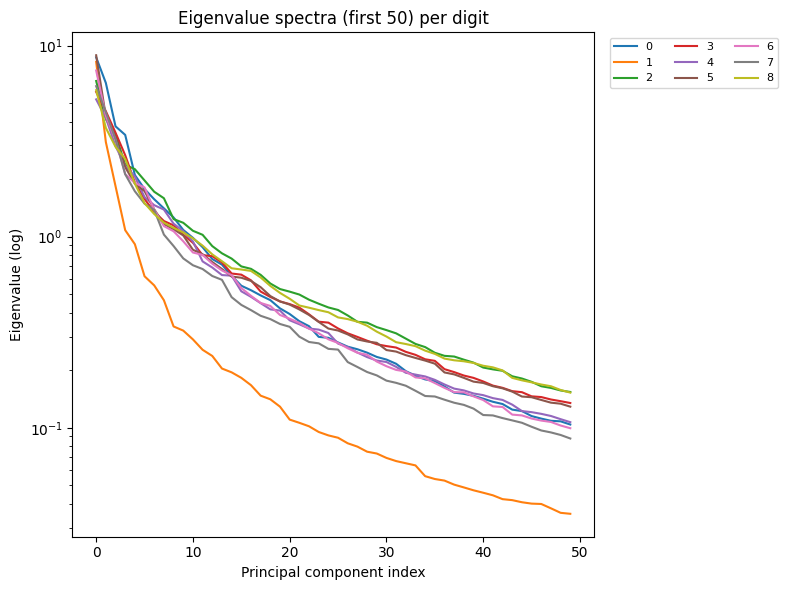

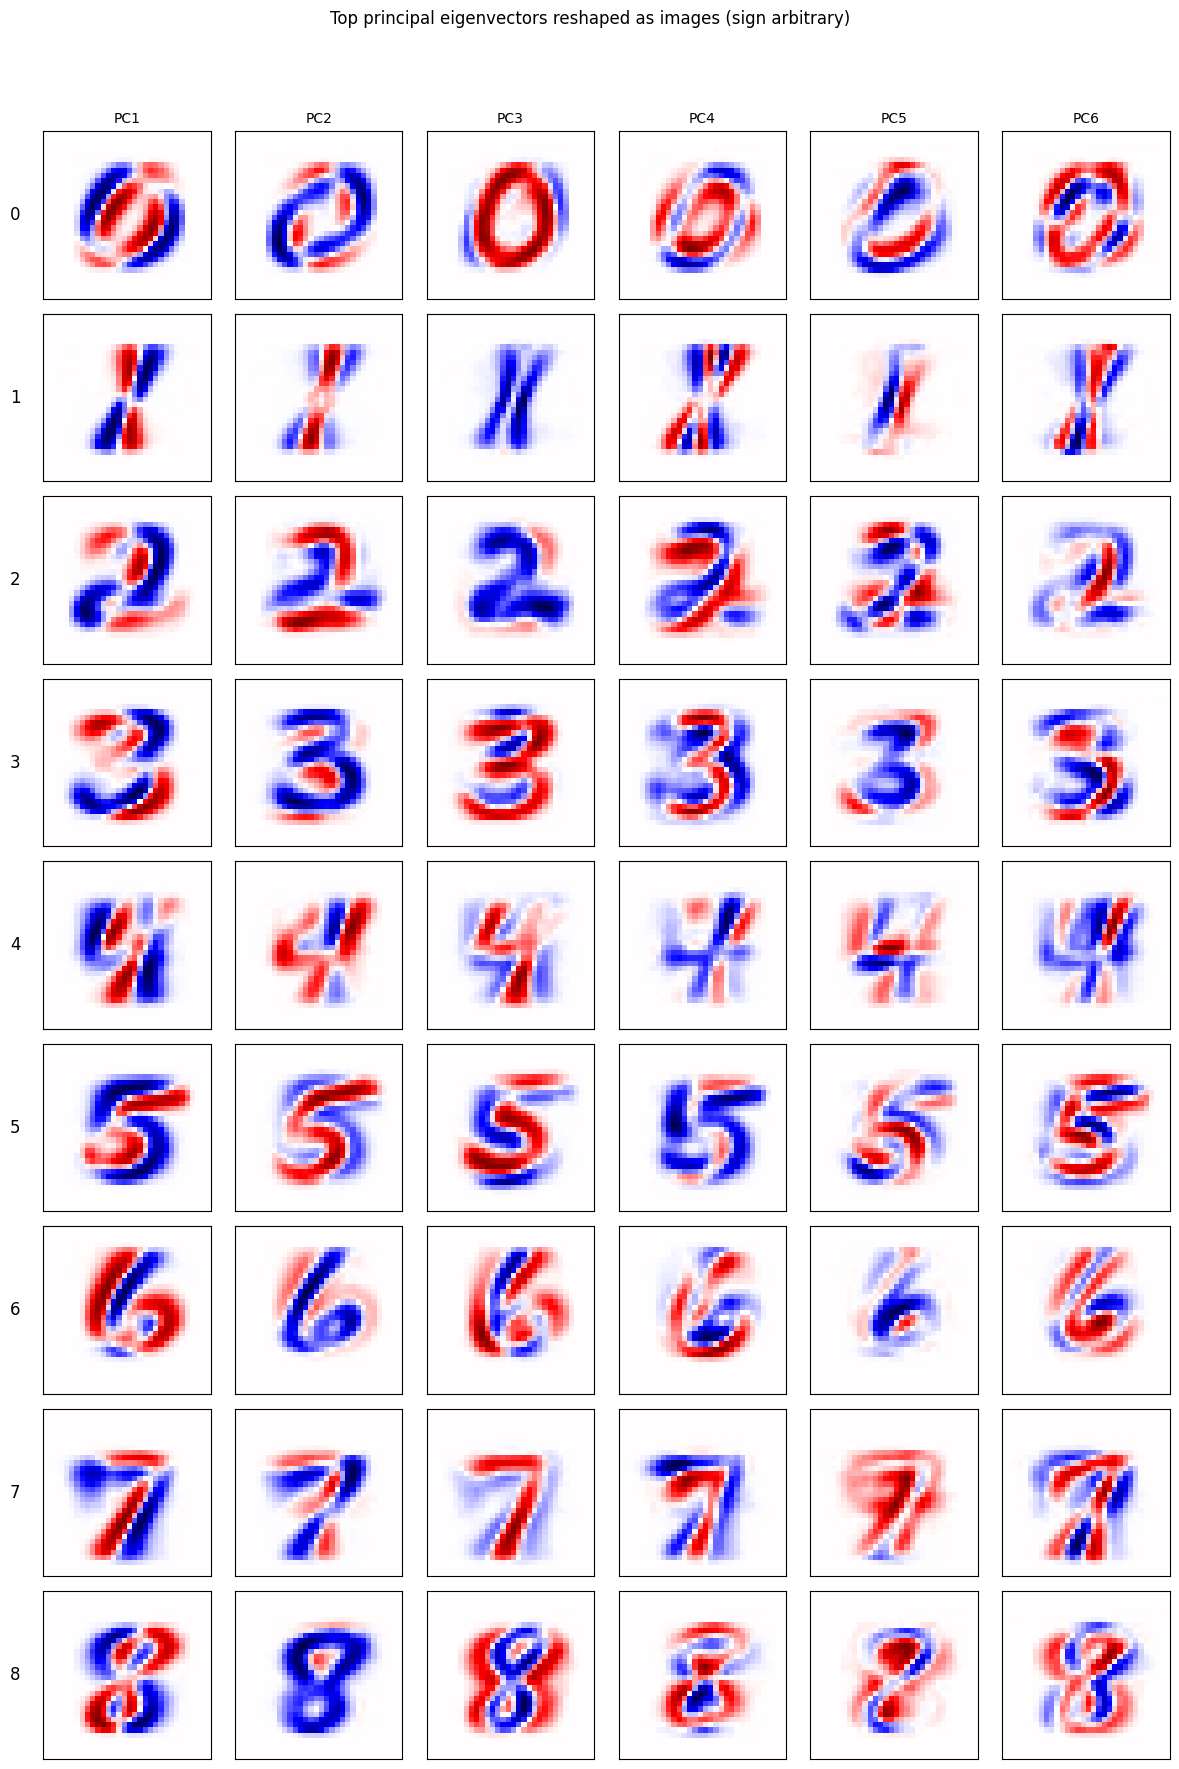

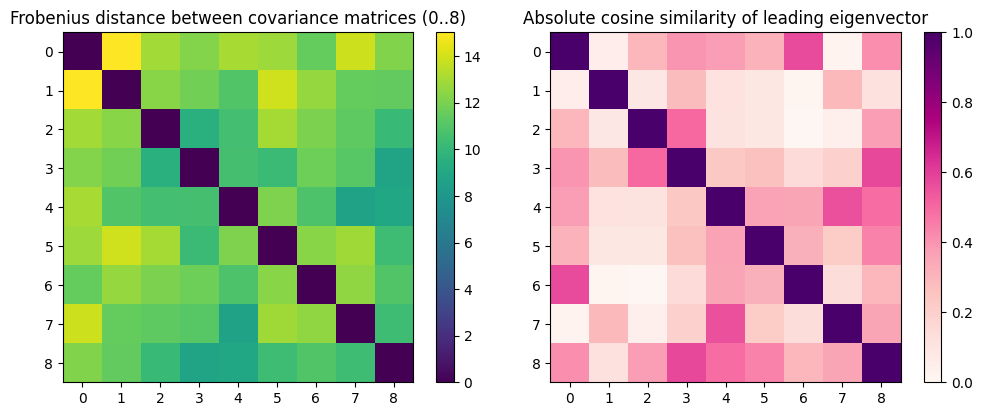

Pairwise covariance Frobenius distances (subset):
[[ 0.         15.03021481 12.93277172 12.21552343 13.05762697 12.85147117
  11.49984127 13.90576073 12.18772715]
 [15.03021481  0.         12.33990496 11.85433295 10.97156045 13.96391903
  12.62400005 11.46845051 11.40685812]
 [12.93277172 12.33990496  0.          9.53978741 10.53976196 13.026965
  12.08807401 11.27912641 10.11874846]
 [12.21552343 11.85433295  9.53978741  0.         10.60776923 10.24785538
  11.71773304 11.13668709  8.78590187]
 [13.05762697 10.97156045 10.53976196 10.60776923  0.         12.13800093
  10.82951588  8.6670272   8.97810995]
 [12.85147117 13.96391903 13.026965   10.24785538 12.13800093  0.
  12.37038422 12.88191411 10.3864323 ]
 [11.49984127 12.62400005 12.08807401 11.71773304 10.82951588 12.37038422
   0.         12.51506732 10.97388172]
 [13.90576073 11.46845051 11.27912641 11.13668709  8.6670272  12.88191411
  12.51506732  0.         10.35769226]
 [12.18772715 11.40685812 10.11874846  8.78590187  8.978

In [4]:
# ...existing code...
import numpy as np
from scipy.linalg import eigh
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

def compute_cov_and_eig(images, flatten=True):
    # images: (N, H, W) or (N, D) if already flattened
    if flatten:
        X = images.reshape(len(images), -1).astype(np.float64) / 255.0
    else:
        X = images.astype(np.float64) / 255.0
    # center
    Xc = X - X.mean(axis=0, keepdims=True)
    # covariance (features in columns -> rowvar=False)
    C = np.cov(Xc, rowvar=False)
    # compute eigenvalues/vectors (sorted desc)
    evals, evecs = eigh(C)
    evals = evals[::-1]
    evecs = evecs[:, ::-1]
    return C, evals, evecs

# parameters
digits = list(range(0, 9))   # first 9 digits (0..8). change to [1..9] if desired
n_per_digit = 1000           # samples per digit (reduce if memory / speed issues)
top_k = 6                    # how many principal eigenvectors to visualize

# load MNIST
(x_train, y_train), _ = mnist.load_data()
# pad to 32x32 like your notebook earlier (optional)
x_train_32 = np.pad(x_train, ((0,0),(2,2),(2,2)), mode='constant', constant_values=0)

covs = {}
evals = {}
evecs = {}

for d in digits:
    imgs = x_train_32[y_train == d][:n_per_digit]
    if len(imgs) == 0:
        raise RuntimeError(f"No images for digit {d}")
    C, ev, evec = compute_cov_and_eig(imgs, flatten=True)
    covs[d] = C
    evals[d] = ev
    evecs[d] = evec

# Pairwise covariance distance (Frobenius norm) matrix
m = len(digits)
cov_dist = np.zeros((m, m))
for i, di in enumerate(digits):
    for j, dj in enumerate(digits):
        cov_dist[i, j] = np.linalg.norm(covs[di] - covs[dj], ord='fro')

# Pairwise leading eigenvector similarity (absolute cosine)
lead_sim = np.zeros((m, m))
for i, di in enumerate(digits):
    v_i = evecs[di][:, 0]
    for j, dj in enumerate(digits):
        v_j = evecs[dj][:, 0]
        # account for sign ambiguity: use absolute dot
        lead_sim[i, j] = abs(np.dot(v_i, v_j)) / (np.linalg.norm(v_i) * np.linalg.norm(v_j))

# Plot: covariance heatmaps (only show a few digits if too many)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, d in zip(axes.flat, digits):
    im = ax.imshow(covs[d], cmap='RdBu_r', vmin=-np.max(np.abs(covs[d])), vmax=np.max(np.abs(covs[d])))
    ax.set_title(f"Cov - digit {d}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.suptitle("Covariance matrices (flattened pixels) for digits 0..8")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Plot eigenvalue spectra for each digit
plt.figure(figsize=(8,6))
for d in digits:
    plt.plot(evals[d][:50], label=str(d))   # first 50 eigenvalues
plt.yscale('log')
plt.xlabel("Principal component index")
plt.ylabel("Eigenvalue (log)")
plt.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.title("Eigenvalue spectra (first 50) per digit")
plt.tight_layout()
plt.show()

# Visualize top-k principal eigenvectors as images per digit
H, W = x_train_32.shape[1], x_train_32.shape[2]  # 32x32
fig, axs = plt.subplots(len(digits), top_k, figsize=(top_k*2, len(digits)*2))
for i, d in enumerate(digits):
    for k in range(top_k):
        vec = evecs[d][:, k]
        img = vec.reshape(H, W)
        ax = axs[i, k] if (len(digits) > 1) else axs[k]
        ax.imshow(img, cmap='seismic', vmin=-np.max(np.abs(img)), vmax=np.max(np.abs(img)))
        if k == 0:
            ax.set_ylabel(str(d), rotation=0, labelpad=20, fontsize=12, va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 0:
            ax.set_title(f"PC{k+1}", fontsize=10)
plt.suptitle("Top principal eigenvectors reshaped as images (sign arbitrary)")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Show pairwise matrices: distances and leading-evec similarity
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(cov_dist, cmap='viridis')
plt.colorbar()
plt.xticks(range(m), digits)
plt.yticks(range(m), digits)
plt.title("Frobenius distance between covariance matrices (0..8)")

plt.subplot(1,2,2)
plt.imshow(lead_sim, cmap='RdPu', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(m), digits)
plt.yticks(range(m), digits)
plt.title("Absolute cosine similarity of leading eigenvector")
plt.tight_layout()
plt.show()

# Print a small numerical summary
print("Pairwise covariance Frobenius distances (subset):")
print(cov_dist)
print("\nPairwise leading eigenvector abs-cosine similarities:")
print(lead_sim)
# ...existing code...